# Expected Loss & Backtesting

In [1]:
import pandas as pd, numpy as np, statsmodels.stats.proportion as smprop, matplotlib.pyplot as plt
df = pd.read_csv('../data/processed/test_predictions.csv')
LGD = 0.45
df['Exposure_Proxy'] = df['Credit_Limit']
df['EL_LR'] = df['PD_LR'] * LGD * df['Exposure_Proxy']
df['EL_RF'] = df['PD_RF_Selected'] * LGD * df['Exposure_Proxy']


### 1. Realized Loss Backtest
This backtest is consistent with (but does not fully 'validate') the PD calibration and Exposure proxy. It cannot validate LGD since the same 45% enters both sides. Note that all variants fall slightly below realized loss, and their estimates are highly correlated.

In [2]:
realized_loss = (df['Actual_Default'] * df['Exposure_Proxy'] * LGD).sum()

np.random.seed(42)
boot_diffs = []
for _ in range(1000):
    idx = np.random.choice(df.index, size=len(df), replace=True)
    b_realized = (df.loc[idx, 'Actual_Default'] * df.loc[idx, 'Exposure_Proxy'] * LGD).sum()
    b_model = df.loc[idx, 'EL_RF'].sum()
    boot_diffs.append(b_model - b_realized)

ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])

res = pd.DataFrame({
    'Metric': ['Realized Loss', 'Model EL (LR)', 'Model EL (RF Selected)'],
    'Value': [realized_loss, df['EL_LR'].sum(), df['EL_RF'].sum()]
})
res['Diff'] = res['Value'] - realized_loss
res['% Diff'] = res['Diff'] / realized_loss * 100
display(res.round(2))
print(f"95% CI of Difference (RF EL - Realized): [{ci_lower:,.0f}, {ci_upper:,.0f}]")


,Metric,Value,Diff,% Diff
0,Realized Loss,82155456.00,0.00,0.00
1,Model EL (LR),76643925.88,-5511530.12,-6.71
2,Model EL (RF Selected),79382917.60,-2772538.40,-3.37


95% CI of Difference (RF EL - Realized): [-7,720,421, 2,208,886]


### 2. 5-Grade Master Scale
Fixed PD cutoffs: 5%, 15%, 30%, 60%. Chosen strictly from PD distribution, not observed outcomes.

,Clients,% Clients,Avg_PD,Obs_Default,Wilson_95CI,Expected_Def,Actual_Def,Exposure,EL,EL_Share
Grade,,,,,,,,,,
1. Very Low (<5%),431,7.183,0.035,0.049,"[0.032, 0.073]",15.084,21,131830000,1.997425e+06,2.516
2. Low (5-15%),2509,41.817,0.103,0.105,"[0.094, 0.118]",258.324,264,489820000,2.183547e+07,27.507
3. Medium (15-30%),1691,28.183,0.203,0.186,"[0.168, 0.205]",344.004,314,232340000,2.097388e+07,26.421
4. High (30-60%),889,14.817,0.428,0.435,"[0.403, 0.468]",380.210,387,107837680,2.029842e+07,25.570
5. Very High (>=60%),480,8.000,0.695,0.710,"[0.668, 0.749]",333.644,341,45950000,1.427773e+07,17.986


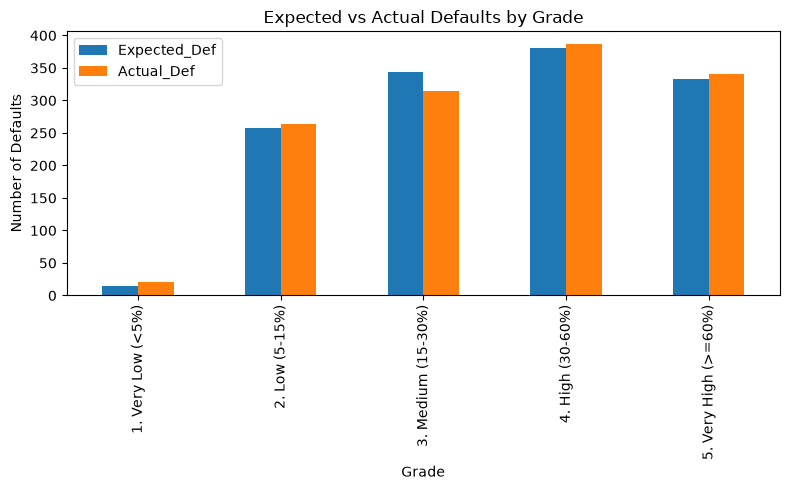

In [3]:
def get_grade(pd_val):
    if pd_val < 0.05: return '1. Very Low (<5%)'
    elif pd_val < 0.15: return '2. Low (5-15%)'
    elif pd_val < 0.30: return '3. Medium (15-30%)'
    elif pd_val < 0.60: return '4. High (30-60%)'
    else: return '5. Very High (>=60%)'

df['Risk_Grade'] = df['PD_RF_Selected'].apply(get_grade)
order = sorted(df['Risk_Grade'].unique())

rows = []
for g in order:
    sub = df[df['Risk_Grade'] == g]
    n = len(sub)
    obs = sub['Actual_Default'].sum()
    ci_low, ci_upp = smprop.proportion_confint(obs, n, method='wilson')
    rows.append({
        'Grade': g, 'Clients': n, '% Clients': n/len(df)*100,
        'Avg_PD': sub['PD_RF_Selected'].mean(),
        'Obs_Default': obs/n, 'Wilson_95CI': f"[{ci_low:.3f}, {ci_upp:.3f}]",
        'Expected_Def': sub['PD_RF_Selected'].sum(), 'Actual_Def': obs,
        'Exposure': sub['Exposure_Proxy'].sum(),
        'EL': sub['EL_RF'].sum()
    })

master = pd.DataFrame(rows).set_index('Grade')
master['EL_Share'] = master['EL'] / master['EL'].sum() * 100
display(master.round(3))

# Plot
master[['Expected_Def', 'Actual_Def']].plot(kind='bar', figsize=(8,5))
plt.title("Expected vs Actual Defaults by Grade")
plt.ylabel("Number of Defaults")
plt.tight_layout()
plt.savefig('../figures/risk_tier_analysis.png', dpi=150)
plt.show()


### 3. Appendix: Initial Cutoffs (Draft 3-Tier)

In [4]:
def get_tier(pd_val):
    if pd_val < 0.05: return 'Low'
    elif pd_val < 0.15: return 'Medium'
    else: return 'High'
df['Risk_Tier'] = df['PD_RF_Selected'].apply(get_tier)
display(df.groupby('Risk_Tier').agg(Clients=('Actual_Default', 'count'), Avg_PD=('PD_RF_Selected', 'mean'), Obs_Default=('Actual_Default', 'mean')).reindex(['Low', 'Medium', 'High']))


,Clients,Avg_PD,Obs_Default
Risk_Tier,,,
Low,431,0.034999,0.048724
Medium,2509,0.102959,0.105221
High,3060,0.345705,0.340523
